In [2]:
import numpy as np
import tarfile
import os
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
np.random.seed(42)

### Učitavanje podataka

In [4]:
if not os.path.exists('data/jpg/'):
    with tarfile.open('data/102flowers.tgz', 'r:gz') as tar:
        tar.extractall(path='data/')

In [5]:
IMG_DIR = Path('data/jpg')
labels_raw = scipy.io.loadmat('data/imagelabels.mat')['labels'].flatten()

In [6]:
image_paths = sorted(IMG_DIR.glob('*.jpg'), key=lambda p: int(p.stem.split('_')[1]))

print(f"Total images: {len(image_paths)}")
print(f"Total labels: {len(labels_raw)}")
print(f"Label range: {labels_raw.min()} - {labels_raw.max()}  ({len(np.unique(labels_raw))} unique classes)")

Total images: 8189
Total labels: 8189
Label range: 1 - 102  (102 unique classes)


In [7]:
df = pd.DataFrame({
    'path': image_paths,
    'label': labels_raw
})
df.head()

,path,label
0,data\jpg\image_00001.jpg,77
1,data\jpg\image_00002.jpg,77
2,data\jpg\image_00003.jpg,77
3,data\jpg\image_00004.jpg,77
4,data\jpg\image_00005.jpg,77


### Analiza podataka

In [8]:
class_counts = df['label'].value_counts().sort_index()
median = class_counts.median()
mean = class_counts.mean()

print(f"Min samples per class: {class_counts.min()} (class {class_counts.idxmin()})")
print(f"Max samples per class: {class_counts.max()} (class {class_counts.idxmax()})")
print(f"Mean: {mean:.1f}")
print(f"Std: {class_counts.std():.1f}")
print(f"Median: {median:.0f}")

Min samples per class: 40 (class 1)
Max samples per class: 258 (class 51)
Mean: 80.3
Std: 44.3
Median: 66


In [9]:
below_median = class_counts[class_counts < int(median)]
over_median  = class_counts[class_counts > int(median)]
print(f"Number of classes over median: {len(over_median)}")
print(f"Number of classes below median: {len(below_median)}")

Number of classes over median: 49
Number of classes below median: 50


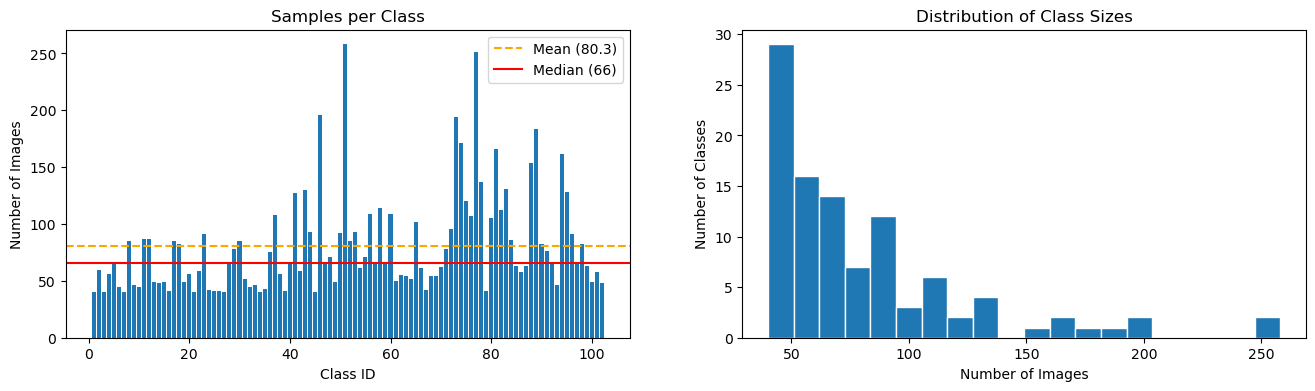

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 4))

ax1.bar(class_counts.index, class_counts.values)
ax1.axhline(class_counts.mean(), color  = "orange", linestyle="--", label = f'Mean ({class_counts.mean():.1f})')
ax1.axhline(class_counts.median(), color = "red", label = f'Median ({class_counts.median():.0f})')
ax1.set_xlabel('Class ID')
ax1.set_ylabel('Number of Images')
ax1.set_title('Samples per Class')
ax1.legend()

ax2.hist(class_counts.values, bins = 20, edgecolor = 'white')
ax2.set_xlabel('Number of Images')
ax2.set_ylabel('Number of Classes')
ax2.set_title('Distribution of Class Sizes')

plt.show()

In [11]:
img_info = []
for p in image_paths:
    try:
        with Image.open(p) as img:
            w, h = img.size
            mode = img.mode
        file_size = os.path.getsize(p)
        img_info.append({'path': p, 'width': w, 'height': h, 'mode': mode, 'file_size': file_size, 'corrupt': False})
    except (UnidentifiedImageError, OSError):
        img_info.append({'path': p, 'width': None, 'height': None, 'mode': None, 'file_size': None, 'corrupt': True})

img_info = pd.DataFrame(img_info)
df = df.merge(img_info.drop(columns=['path']), left_index=True, right_index=True)
df.head()

,path,label,width,height,mode,file_size,corrupt
0,data\jpg\image_00001.jpg,77,591.0,500.0,RGB,49057.0,False
1,data\jpg\image_00002.jpg,77,625.0,500.0,RGB,57207.0,False
2,data\jpg\image_00003.jpg,77,500.0,667.0,RGB,57837.0,False
3,data\jpg\image_00004.jpg,77,667.0,500.0,RGB,56469.0,False
4,data\jpg\image_00005.jpg,77,508.0,500.0,RGB,52293.0,False


Number of valid images: 8188
Width:  min: 500.0, max: 1024.0, mean: 630, std: 96
Height: min: 500.0, max: 1168.0, mean: 534, std: 75
Color modes  : {'RGB': 8188}


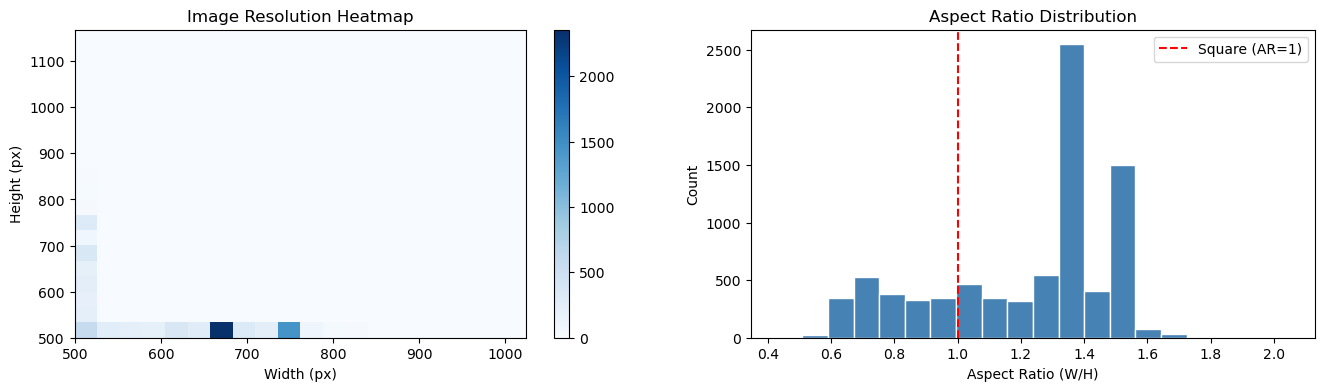

In [12]:
valid = df[~df['corrupt']]
print(f"Number of valid images: {len(valid)}")
print(f"Width:  min: {valid['width'].min()}, max: {valid['width'].max()}, "
      f"mean: {valid['width'].mean():.0f}, std: {valid['width'].std():.0f}")
print(f"Height: min: {valid['height'].min()}, max: {valid['height'].max()}, "
      f"mean: {valid['height'].mean():.0f}, std: {valid['height'].std():.0f}")
print(f"Color modes  : {valid['mode'].value_counts().to_dict()}")

valid = valid.copy()
valid['aspect_ratio'] = valid['width'] / valid['height']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.hist2d(valid['width'], valid['height'], bins=20, cmap='Blues')
ax1.set_xlabel('Width (px)'); ax1.set_ylabel('Height (px)')
ax1.set_title('Image Resolution Heatmap')
plt.colorbar(ax1.collections[0], ax=ax1)

ax2.hist(valid['aspect_ratio'], bins=20, color='steelblue', edgecolor='white')
ax2.axvline(1.0, color='red', linestyle='--', label='Square (AR=1)')
ax2.set_xlabel('Aspect Ratio (W/H)'); ax2.set_ylabel('Count')
ax2.set_title('Aspect Ratio Distribution')
ax2.legend()

plt.show()


In [13]:
corrupt_df = df[df['corrupt'] == True]
print(f"Corrupt images : {len(corrupt_df)}")

tiny_threshold_kb = 2.0
tiny = df[(~df['corrupt']) & (df['file_size'] < tiny_threshold_kb * 1024)]
print(f"Very small files (< {tiny_threshold_kb} kB): {len(tiny)}")

non_rgb = df[(~df['corrupt']) & (df['mode'] != 'RGB')]
print(f"Non-RGB images: {len(non_rgb)}")


Corrupt images : 1
Very small files (< 2.0 kB): 0
Non-RGB images: 0


In [14]:
if(len(corrupt_df) > 0):
    df.drop(corrupt_df.index, inplace=True)

print("Number of images after deleting corrupted: ", len(df))

Number of images after deleting corrupted:  8188


In [15]:
class_ids = np.random.choice(np.unique(df['label'].values), size=20, replace=False)
class_ids.sort()

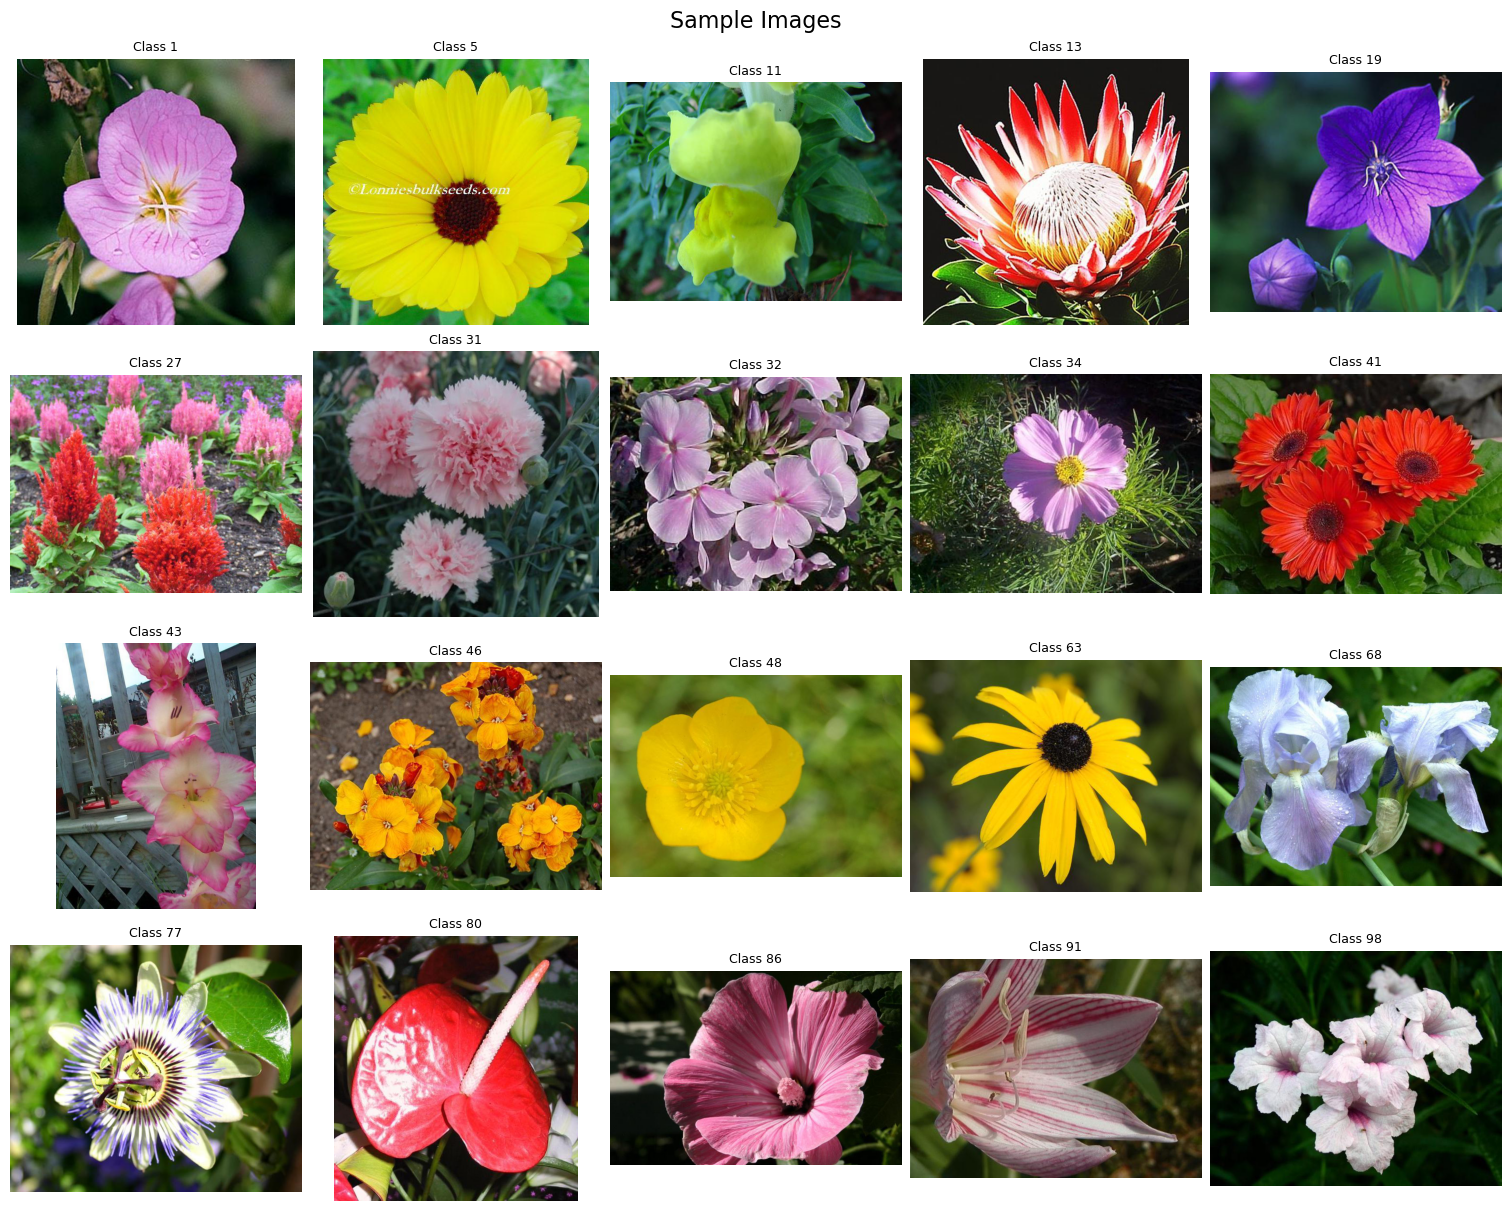

In [16]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for ax, id in zip(axes, class_ids):
    sample_path = df[df['label'] == id]['path'].iloc[0]
    img = Image.open(sample_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'Class {id}', fontsize=9)
    ax.axis('off')

fig.suptitle('Sample Images', fontsize=16)
fig.set_layout_engine('constrained')
plt.show()

In [17]:
channel_stats = []
for id in np.unique(df['label'].values):
    rows = df[df['label'] == id].sample(5, random_state=42)
    pixels = []
    for p in rows['path']:
        arr = np.array(Image.open(p).convert('RGB').resize((64, 64))) / 255.0
        pixels.append(arr.reshape(-1, 3))
    if pixels:
        pix = np.vstack(pixels)
        channel_stats.append({'class': id,
                               'mean_R': pix[:, 0].mean(), 'mean_G': pix[:, 1].mean(), 'mean_B': pix[:, 2].mean(),
                               'std_R':  pix[:, 0].std(),  'std_G':  pix[:, 1].std(),  'std_B':  pix[:, 2].std()})

stats_df = pd.DataFrame(channel_stats)

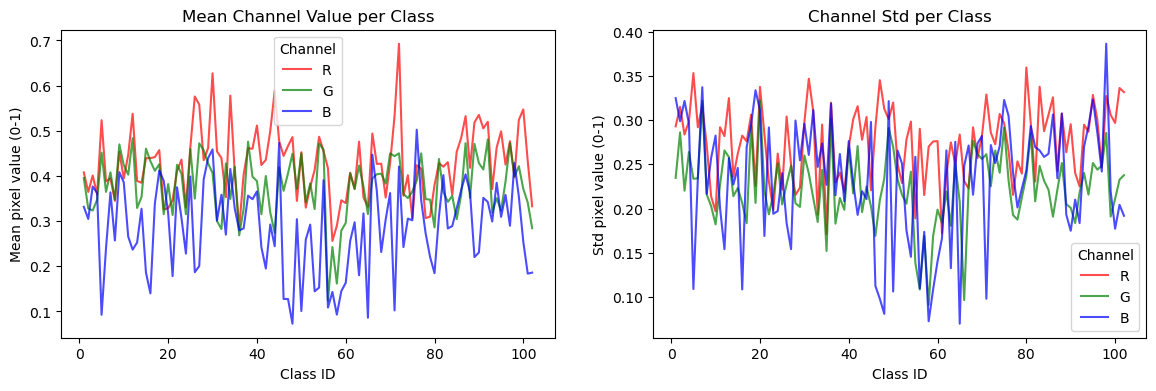

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ch, color in zip(['R', 'G', 'B'], ['red', 'green', 'blue']):
    axes[0].plot(stats_df['class'], stats_df[f'mean_{ch}'], color=color, alpha=0.7, label=ch)
axes[0].set_xlabel('Class ID'); axes[0].set_ylabel('Mean pixel value (0-1)')
axes[0].set_title('Mean Channel Value per Class')
axes[0].legend(title='Channel')

for ch, color in zip(['R', 'G', 'B'], ['red', 'green', 'blue']):
    axes[1].plot(stats_df['class'], stats_df[f'std_{ch}'], color=color, alpha=0.7, label=ch)
axes[1].set_xlabel('Class ID'); axes[1].set_ylabel('Std pixel value (0-1)')
axes[1].set_title('Channel Std per Class')
axes[1].legend(title='Channel')

plt.show()

Na grafu srednjih vrednosti pojedinačnih RGB kanala (vrednosti su dobijene na osnovu 5 primeraka iz svake klase) vidimo da je crvena dominantna boja u svim klasama, što ima smisla kada je u pitanju cveće - latice su pretežno toplih boja (crvene, ružičaste, žute, narandžaste i sl.). Zelena je uglavnom stabilna što odgovara činjenici da vaćina slika sadrži zelenu pozadinu, nevezano za boju cveta. Plava je najmanje zastupljena što je u skladu sa prethodna dva zapažanja. 

Boje značajno variraju među klasama, te procenjujemo da nose i značajnu informaciju u prepoznavanju klase.

Desni grafik se odnosi na standardnu devijaciju boja. NA nivou klasa varijacija boja je prilcno visoka, tj. slike sadrže raznovrsne intenzitete boja,a crvena boja ponovo ima najveće vrednosti. Kod nekih klasa primećuje se niska devijacija za određene kanale (primarno plavi i zeleni) što ukazuje na vizuelnu homogenost, tj. uniformnost boja, te će se možda ove klase pokazati lakšim za klasifikaciju.

### Preprocesiranje

In [19]:
IMG_SIZE   = (128, 128)   # (H, W) — change to 224 for pretrained CNN backbones
PIXEL_MEAN = np.array([0.485, 0.456, 0.406])   # ImageNet stats (good starting point)
PIXEL_STD  = np.array([0.229, 0.224, 0.225])

In [20]:
def load_and_transform(path, size=IMG_SIZE):
    with Image.open(path) as img:
        img = img.convert('RGB').resize((size[1], size[0]), Image.BILINEAR)
    return np.array(img, dtype=np.float32) / 255.0

In [21]:
def normalize(arr, mean=PIXEL_MEAN, std=PIXEL_STD):
    return (arr - mean) / std

In [22]:
sample_arr = load_and_transform(df['path'].iloc[0])
print(f"Preprocessed array shape : {sample_arr.shape}  dtype: {sample_arr.dtype}")
print(f"Pixel range before norm  : [{sample_arr.min():.3f}, {sample_arr.max():.3f}]")
norm_arr = normalize(sample_arr)
print(f"Pixel range after norm   : [{norm_arr.min():.3f}, {norm_arr.max():.3f}]")

Preprocessed array shape : (128, 128, 3)  dtype: float32
Pixel range before norm  : [0.000, 1.000]
Pixel range after norm   : [-2.084, 2.640]


Sve slike transofrmišemo na veličinu određenu sa `IMG_SIZE`. Zatim se od nje pravi vektor vrednosti u rasponu [0.0, 1.0], nad kojim se vrši normalizacija na nivou RGB kanala koristeći srednje vrednosti iz `PIXEL_MEAN` i `PIXEL_STD`. Rezultati ove obrade date su na slici ispod. 

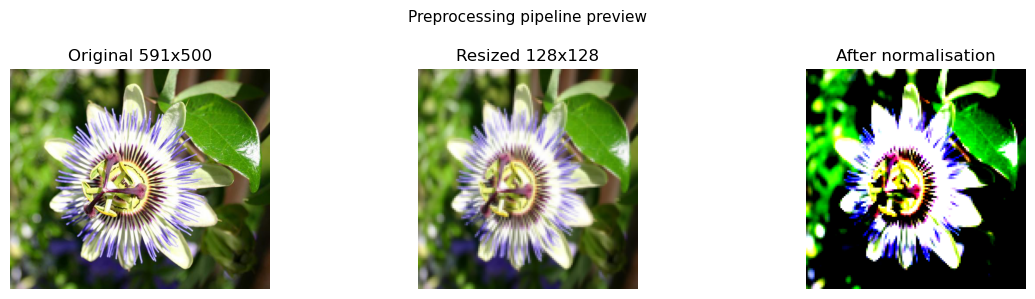

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
sample_path = df['path'].iloc[0]
orig = np.array(Image.open(sample_path).convert('RGB'))
resized = (sample_arr * 255).astype(np.uint8)

axes[0].imshow(orig)
axes[0].set_title(f'Original {orig.shape[1]}x{orig.shape[0]}')
axes[0].axis('off')

axes[1].imshow(resized)
axes[1].set_title(f'Resized {IMG_SIZE[1]}x{IMG_SIZE[0]}')
axes[1].axis('off')

axes[2].imshow(np.clip(norm_arr, 0, 1))
axes[2].set_title('After normalisation')
axes[2].axis('off')

plt.suptitle('Preprocessing pipeline preview', fontsize=11)
plt.tight_layout()
plt.show()

### Train/Validation/Test 

Skup podataka delimo na skup za treniranje, validaciju i testiranje u razmeri 70:15:15. Vrsena je i stratifikacija prema ciljnoj promenljivoj, tj. klasi za obezbedjivanje proporcionalne prisutnosti klasa u svakom skupu. 

In [24]:
X = df['path'].values
y = df['label'].values
idx = np.arange(len(df))

In [25]:
X_train_val, X_test, y_train_val, y_test, itr, ite = train_test_split(X, y, idx, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val, itr, iva = train_test_split(X_train_val, y_train_val, itr, test_size=0.15 / 0.85, stratify=y_train_val, random_state=42)

### Kernelizovani K Nearest Neighbors

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import rbf_kernel

In [52]:
KNN_IMG_SIZE = (64, 64)

#### [Kernel kao tezine](https://learningfromdata.netlify.app/pdfs/kknn/kknn_presentation.pdf)

Funkcija `rbf_weights` sluzi za racunanje tezina svakog suseda. Tezina je odredjena na osnovu RBF (Gausovog) kernela nad distancama:
$$ w_i = e^{-\gamma d_i^2} $$

Bliži susedi imaju veću težinu, a $\gamma$ određuje koliko "brzo" uticaj opada.

In [53]:
def rbf_weights(distances, gamma):
    return np.maximum(np.exp(-gamma * distances ** 2), 1e-12)

In [54]:
def build_feature_matrix(paths, size=KNN_IMG_SIZE):
    feats = np.empty((len(paths), size[0] * size[1] * 3), dtype=np.float32)
    for i, p in enumerate(paths):
        img = load_and_transform(p, size)
        feats[i] = img.ravel()
    return feats

In [55]:
X_train_feat = build_feature_matrix(X_train, size=KNN_IMG_SIZE)
X_val_feat = build_feature_matrix(X_val, size=KNN_IMG_SIZE)
X_test_feat = build_feature_matrix(X_test, size=KNN_IMG_SIZE)

In [56]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled = scaler.transform(X_val_feat)
X_test_scaled = scaler.transform(X_test_feat)

In [57]:
# klasican model
knn_classic = KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1)
knn_classic.fit(X_train_scaled, y_train)

y_val_pred_classic = knn_classic.predict(X_val_scaled)
print("Validation accuracy for classic KNN (k = 5): ", accuracy_score(y_val, y_val_pred_classic))

Exception in thread Thread-10 (_readerthread):
Traceback (most recent call last):
  File "c:\ProgramData\miniconda3\envs\ai\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\ProgramData\miniconda3\envs\ai\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\ProgramData\miniconda3\envs\ai\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x84 in position 37: invalid start byte


Validation accuracy for classic KNN (k = 5):  0.14320585842148087


In [58]:
gamma = 1.0 / X_train_scaled.shape[1]  # 1 / broj atributa * varijansa (skup je normalizovan pa je varijansa 1)
knn_kernel = KNeighborsClassifier(n_neighbors=15, weights=lambda d: rbf_weights(d, gamma), n_jobs=-1)
knn_kernel.fit(X_train_scaled, y_train)

y_val_pred_kernel = knn_kernel.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, y_val_pred_kernel)
print("Validation accuracy for RBF KNN (k = 15): ", val_accuracy)

Validation accuracy for RBF KNN (k = 15):  0.14320585842148087


##### Hiperparametri k i $\gamma$ za kernelizovani KNN

In [59]:
k_values = [5, 11, 15, 21, 31, 51]
gamma_values = [0.0001, 0.001, 0.01, 0.1, 1, 10] 


In [60]:
results = []
for k in k_values:
    for g in gamma_values:
        model = KNeighborsClassifier(n_neighbors=k, weights=lambda d, g=g: rbf_weights(d, g), n_jobs=-1) # g=g uzima trenutnu vr g, a ne onu kada se pozove funkcija
        model.fit(X_train_scaled, y_train)

        acc = accuracy_score(y_val, model.predict(X_val_scaled))
        results.append({"k": k, "gamma": g, "acc": acc})
                       

In [61]:
best = results[np.argmax([r['acc'] for r in results])]
print("Best hyperparameters: ", best)

Best hyperparameters:  {'k': 51, 'gamma': 0.001, 'acc': 0.17168429617575265}


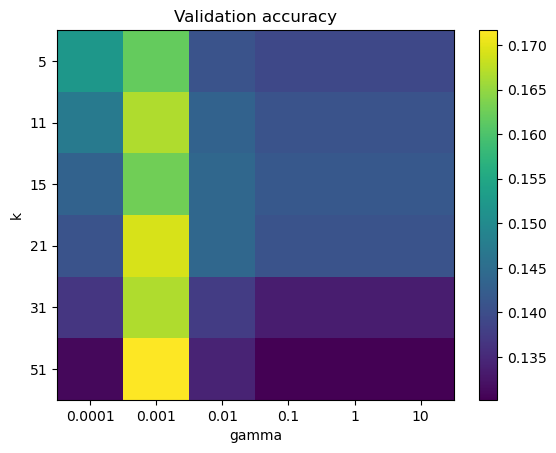

In [62]:
res_df = pd.DataFrame(results)
pivot = res_df.pivot(index = "k", columns = "gamma", values = "acc")

fig, ax = plt.subplots()
im = ax.imshow(pivot.values, aspect = "auto")

ax.set_xticks(range(len(pivot.columns))) 
ax.set_xticklabels([f'{g:g}' for g in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_xlabel("gamma")
ax.set_ylabel("k")
ax.set_title("Validation accuracy")
plt.colorbar(im, ax=ax)
plt.show()

In [63]:
final = KNeighborsClassifier(n_neighbors=best['k'], weights=lambda d: rbf_weights(d, best['gamma']), n_jobs=-1)
final.fit(X_train_scaled, y_train)

y_test_pred = final.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test accuracy: ", test_accuracy)
print(classification_report(y_test, y_test_pred, digits=4, zero_division=0))

KeyboardInterrupt: 

#### Kernel kao rastojanje

[Rastojanje indukovano kernelom](https://arxiv.org/pdf/1103.1625) mozemo definsati kao:
$$ d(x, x') = sqrt(K(x,x) + K(x',x') - 2K(x,x')) = sqrt(2 - 2K(x,x'))$$
Za normalizovane kernele gde $K(x,x) = 1$ indukovano rastojanje je onda:
$$ d(x, x') = sqrt(2 - 2K(x,x'))$$

Koristicemo $\chi^2$ kernel, jer je njegovo "geometrijsko ponasanje" drugacije od Euklidskog rastojanja.
$$K(x,x') = e^{-\gamma \frac{(x - x')^2}{x + x'}} $$
Ovo ne vazi i za RBF:
$$ K(x, x') = e^{-\gamma ||x-x'||^2} $$
$||x-x'||^2$ je kvadratno Euklidsko rastojanje, te mozemo reci da je rastojanje indukovano RBF kernelom monotona funkcija nad Euklidskim rastojanjima. Dakle blizim tackama RBF kernel dodeljuje vecu slicnost. Zbog ovoga ce "nabrajanje" suseda biti identicno kao da smo koristili Euklidski KNN. 

**Opisane kernel funkcije su u "sustini" iste, tj. razlikuju se na osnovu metrike rastojanja**

In [ ]:
from sklearn.metrics.pairwise import chi2_kernel
from sklearn.metrics.pairwise import additive_chi2_kernel

In [ ]:
#chi2 zahteva nenegativne ulaze, koristiti vr piksela na skali [0,1] a ne sklairane StandardScalareom
def chi2_distance(A, B, gamma):
    K = chi2_kernel(A, B, gamma=gamma)
    return np.sqrt(np.maximum(0, 2.0 - 2.0 * K))  # samo nenegativne vrednosti jer koristimo metric="precomputed"

In [ ]:
gamma = 1.0 / X_train_feat.shape[1]  # 1 / broj atributa * varijansa (skup je normalizovan pa je varijansa 1)
d_train = chi2_distance(X_train_feat, X_train_feat, gamma)
d_val = chi2_distance(X_val_feat, X_train_feat, gamma)

knn_chi2 = KNeighborsClassifier(n_neighbors=15, metric='precomputed', weights="distance", n_jobs=-1)
knn_chi2.fit(d_train, y_train)
print("Validation accuracy for Chi2 KNN (k = 15):", accuracy_score(y_val, knn_chi2.predict(d_val)))

Validation accuracy for Chi2 KNN (k = 15): 0.14401952807160293


#### Hiperparametri $\gamma$ i k

In [ ]:
def chi2_dist_from_s(s, gamma):
    K = np.exp(gamma * s)
    return np.sqrt(np.maximum(0, 2.0 - 2.0 * K))

In [ ]:
s_train = additive_chi2_kernel(X_train_feat, X_train_feat)
s_val = additive_chi2_kernel(X_val_feat, X_train_feat)

In [ ]:
k_values = [5, 11, 15, 21, 31, 51]
gamma_values = [0.0001, 0.001, 0.01, 0.1, 1, 10] 

In [ ]:
results_chi2 = []
for g in gamma_values:
    d_train = chi2_dist_from_s(s_train, g)
    d_val = chi2_dist_from_s(s_val, g)
    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k, metric='precomputed', weights="distance", n_jobs=-1)
        model.fit(d_train, y_train)
        acc = accuracy_score(y_val, model.predict(d_val))
        results_chi2.append({"k": k, "gamma": g, "acc": acc})

In [ ]:
best = results_chi2[np.argmax([r['acc'] for r in results_chi2])]
print("Best hyperparameters: ", best)

Best hyperparameters:  {'k': 5, 'gamma': 0.0001, 'acc': 0.1529698942229455}


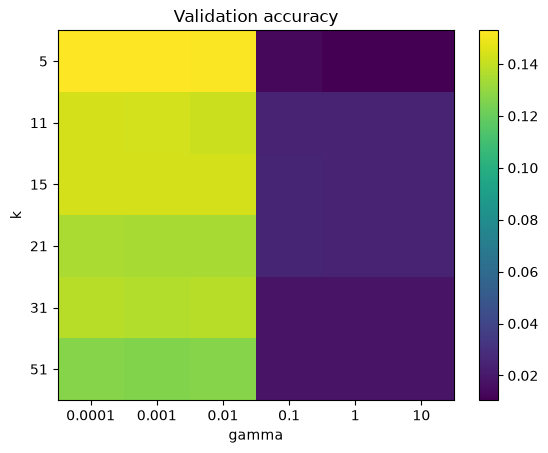

In [ ]:
res_df = pd.DataFrame(results_chi2)
pivot = res_df.pivot(index = "k", columns = "gamma", values = "acc")

fig, ax = plt.subplots()
im = ax.imshow(pivot.values, aspect = "auto")

ax.set_xticks(range(len(pivot.columns))) 
ax.set_xticklabels([f'{g:g}' for g in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

ax.set_xlabel("gamma")
ax.set_ylabel("k")
ax.set_title("Validation accuracy")
plt.colorbar(im, ax=ax)
plt.show()

### [HOG - Histogram orijentisanih gradijenata](https://www.kaggle.com/code/brendan45774/hog-features-histogram-of-oriented-gradients)

https://en.wikipedia.org/wiki/Histogram_of_oriented_gradients

In [ ]:
from skimage.feature import hog

HOG_SIZE = (128, 128)

In [ ]:
def hog_features(path, size=HOG_SIZE):
    with Image.open(path) as img:
        img = img.convert('RGB').resize((size[1], size[0]), Image.BILINEAR)
    gray = np.array(img.convert('L'), dtype=np.float32)
    return hog(gray, pixels_per_cell=(16, 16), cells_per_block=(2, 2), block_norm="L2-Hys", feature_vector=True) 

### [HSV izdvajanje atributa](https://iopscience.iop.org/article/10.1088/1742-6596/2017/1/012010/pdf)

In [ ]:
from skimage.color import rgb2hsv

HSV_SIZE = (128, 128)

In [ ]:
def hsv_hist(path, bins=(8, 8, 8), size=HSV_SIZE):
    with Image.open(path) as img:
        img = img.convert('RGB').resize((size[1], size[0]), Image.BILINEAR)
    hsv = rgb2hsv(np.array(img, dtype=np.float32) / 255.0)
    hist= np.histogramdd(hsv.reshape(-1, 3), bins=bins, range=((0, 1), (0, 1), (0, 1)))[0].ravel()
    return hist / (hist.sum() + 1e-6)  # L1 normalizacija

#### Matrica `Chi2` rastojanja na osnovu izdvojenih atributa

In [ ]:
paths = df['path'].values
hog_all = np.stack([hog_features(p) for p in paths]).astype(np.float32)
hsv_all = np.stack([hsv_hist(p) for p in paths]).astype(np.float32)

print(hog_all.shape, hsv_all.shape)

(8188, 1764) (8188, 512)


In [ ]:
def make_chi2_matrices(features_all, itr, iva, ite, gamma):
    features_tr, features_va, features_te = features_all[itr], features_all[iva], features_all[ite]
    D_tr = chi2_distance(features_tr, features_tr, gamma)
    D_va = chi2_distance(features_va, features_tr, gamma) 
    D_te = chi2_distance(features_te, features_tr, gamma)   
    return D_tr, D_va, D_te

In [ ]:
def eval_precomputed_KNN(D_tr, D_va, y_tr, y_va, k = 15):
    model = KNeighborsClassifier(n_neighbors = k, metric = "precomputed", weights = "distance", n_jobs = -1)
    model.fit(D_tr, y_tr)
    y_va_pred = model.predict(D_va)
    acc = (y_va_pred == y_va).mean()
    return y_va_pred, acc

In [ ]:
gamma_hog = 1.0 / hog_all.shape[1]
gamma_hsv = 1.0 / hsv_all.shape[1]

# D_hog_tr, D_hog_va, D_hog_te = make_chi2_matrices(hog_all, X_train.index, X_val.index, X_test.index, gamma_hog)
Dhog_tr, Dhog_va, Dhog_te = make_chi2_matrices(hog_all, itr, iva, ite, gamma_hog)
Dhsv_tr, Dhsv_va, Dhsv_te = make_chi2_matrices(hsv_all, itr, iva, ite, gamma_hsv)

In [ ]:
gamma_hog, gamma_hsv

(0.0005668934240362812, 0.001953125)

In [ ]:
# comb = 0.5D1 + 0.5D2 - podjednako ucestvuju -> restujemo ih tkd D_novo = D / D.mean() => D_novo.mean() = 1
def normalize_D(D):
    return D / (D.mean() + 1e-6)

Dcomb_tr = 0.5 * normalize_D(Dhog_tr) + 0.5 * normalize_D(Dhsv_tr)
Dcomb_va = 0.5 * normalize_D(Dhog_va) + 0.5 * normalize_D(Dhsv_va)

_, acc_comb = eval_precomputed_KNN(Dcomb_tr, Dcomb_va, y_train, y_val)
print("Validation accuracy for combined HOG + HSV KNN (k = 15): ", acc_comb)

Validation accuracy for combined HOG + HSV KNN (k = 15):  0.3954434499593165


### Hiperparametri $\gamma$, k i w

`chi2_distance` računa vrednost krenel funkcije $K$ na osnovu koje se dobija distanca kao $\sqrt{2-2K}$. $\gamma$ određuje koliko naglo opada slicnost:
- za male vrednosti $\gamma$: K je blisko 1 pa objekti izgledaju relativno slično jer su dobijena rastojanja mala, tj. kontrast između bliskih i udaljenih tačaka je mala
- za velike vrednosti $\gamma$: K naglo opada, tj. sličnost se brzo smanjuje čak i za male razlike, pa su rastojanja izraženija i lkaše se razlikuju bliske od udaljenih tačaka 

Hiperparametar $\gamma$ biramo odvojeno za HOG i HSV izdvojene atribute. 

In [ ]:
s_hog_tr = additive_chi2_kernel(hog_all[itr], hog_all[itr])
s_hog_va = additive_chi2_kernel(hog_all[iva], hog_all[itr])
s_hog_te = additive_chi2_kernel(hog_all[ite], hog_all[itr])

s_hsv_tr = additive_chi2_kernel(hsv_all[itr], hsv_all[itr])
s_hsv_va = additive_chi2_kernel(hsv_all[iva], hsv_all[itr])
s_hsv_te = additive_chi2_kernel(hsv_all[ite], hsv_all[itr])

Za odabir skupa vrednosti $\gamma$ hiperparametra, možemo koristiti [heuristiku zasnovanu na medijani](https://arxiv.org/pdf/1707.07269).
Uopštimo zapis naše kernel funkcije:
$$K(x, y) = exp(- \frac {d(x,y)}{2\sigma^2})$$
gde je $d(x,y)$ rastojanje ($\chi^2$ u nasem slucaju), $\sigma$ širina kernela.
Prethodno smo koristili parametrizaciju sa $\gamma$, a očigledna veza između zapisa je $\gamma = \frac{1}{2\sigma^2}$
U povezanom radu, autori navode da ako je $m$ medijana nad skupom distanci, širina kernela $\sigma$ sa može izabrati kao $\sigma = \sqrt{\frac {m}{2}}$. Dakle $\gamma = \frac{1}{m}$. 

Za naše potrebe računaćemo medijanu $m$ na osnovu rastojanja u trening skupu, a vrednosti za $\gamma$ biramo tako da $m\gamma \approx 1$, što rezultuje u $K = e^{-1} \approx 0.37$. Ako bi medijanu rastojanja tumačili kao "tipično rastojanjne" u skupu, onda za "tipičan" par sličnost ne bi trebala da bude ni blizu jedinice ni blizu nule, već negde između. Dakle ovakvim izborom parametra $\gamma$ sledovala bi dobra raspršenost vrednosti $K$. Ili barem tako predpostavljamo...

In [ ]:
med_hog = np.median(np.abs(s_hog_tr[s_hog_tr < 0])) # < 0 izuzimamo dijagonale, <0 jer funkcija additive_chi2_kernel negira sumu chi2 rastojanja 
med_hsv = np.median(np.abs(s_hsv_tr[s_hsv_tr < 0])) # < 0 izuzimamo dijagonale

gamma_hog_values = np.array([0.1, 0.25, 0.5, 1, 2, 4]) / med_hog
gamma_hsv_values = np.array([0.1, 0.25, 0.5, 1, 2, 4]) / med_hsv

In [ ]:
# provera
g = 1.0 / med_hog
K_sample = np.exp(g * s_hog_tr)
print(K_sample.min(), K_sample.max(), K_sample.mean())

0.06734891 1.0 0.36984307


Po poretpostavci dobili smo finu raspršenost $K$. Naravno ovo ne mora da bude tačno jer smo zaključak izveli samo na osnovu minimuma i maksimuma, ali nećemo se udubljivati u dalju analizu u okviru ovog projekta.

In [ ]:
weights = np.linspace(0, 1, 11)
k_values = [5, 11, 15, 21, 31, 51]
results_comb = []
for g_hog in gamma_hog_values:
    Dhog_tr = chi2_dist_from_s(s_hog_tr, g_hog)
    Dhog_va = chi2_dist_from_s(s_hog_va, g_hog)
    Dhog_tr_n, Dhog_va_n = normalize_D(Dhog_tr), normalize_D(Dhog_va)

    for g_hsv in gamma_hsv_values:
        Dhsv_tr = chi2_dist_from_s(s_hsv_tr, g_hsv)
        Dhsv_va = chi2_dist_from_s(s_hsv_va, g_hsv)
        Dhsv_tr_n, Dhsv_va_n = normalize_D(Dhsv_tr), normalize_D(Dhsv_va)

        for w in weights:
            Dcomb_tr = w * Dhog_tr_n + (1 - w) * Dhsv_tr_n
            Dcomb_va = w * Dhog_va_n + (1 - w) * Dhsv_va_n

            for k in k_values:
                _, acc = eval_precomputed_KNN(Dcomb_tr, Dcomb_va, y_train, y_val, k = k)
                results_comb.append({"gamma_hog": g_hog, "gamma_hsv": g_hsv, "weight": w, "k": k, "acc": acc})

best_comb = max(results_comb, key = lambda r: r["acc"])
print("Best combination for HOG + HSV: ", best_comb)

Best combination for HOG + HSV:  {'gamma_hog': np.float64(0.0028021619609934403), 'gamma_hsv': np.float64(2.5170039981696934), 'weight': np.float64(0.2), 'k': 5, 'acc': np.float64(0.4564686737184703)}


In [ ]:
w = best_comb["weight"]
k = best_comb["k"]
g_hog = best_comb["gamma_hog"]
g_hsv = best_comb["gamma_hsv"]

Dhog_tr = chi2_dist_from_s(s_hog_tr, g_hog)
Dhog_te = chi2_dist_from_s(s_hog_te, g_hog)

Dhsv_tr = chi2_dist_from_s(s_hsv_tr, g_hsv)
Dhsv_te = chi2_dist_from_s(s_hsv_te, g_hsv)

Dcomb_tr = w * normalize_D(Dhog_tr) + (1 - w) * normalize_D(Dhsv_tr)
Dcomb_te = w * normalize_D(Dhog_te) + (1 - w) * normalize_D(Dhsv_te)

y_test_pred, test_acc = eval_precomputed_KNN(Dcomb_tr, Dcomb_te, y_train, y_test, k = k)
print(f"Test accuracy for combined HOG + HSV KNN: ", test_acc)

Test accuracy for combined HOG + HSV KNN:  0.4597233523189585


### Kernelizovani Support Vector Machine

Za konstrukciju modela klasifikaicje baziran na potpornim vektorima koristicemo `skleanr.svm.SVC`. Bitno je napomenuti da ce kernelizacija ove metode biti zasnovana na razmatranju kernel funkcije iskljucivo kao funkcije slicnosti. 

In [ ]:
from sklearn.svm import SVC

### RBF kernel na nivou piksela

In [ ]:
gamma = 1.0 / X_train_scaled.shape[1]
svm_rbf = SVC(kernel='rbf', C=1.0, gamma=gamma, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

y_val_pred_svm = svm_rbf.predict(X_val_scaled)
print("Validation accuracy for RBF SVM:", accuracy_score(y_val, y_val_pred_svm))

Validation accuracy for RBF SVM: 0.2921074043938161


Mnogo je zanimljivije koristiti izdvojene HOG i HSV atribute, a kako oni u svojoj sustini predstavljaju histograme, u okviru kernel funkcije koristimo $\chi^2$ rastojanje.

In [ ]:
def chi2_kernel_from_s(s, gamma):
    K = np.exp(gamma * s) # K je matrica slicnosti
    return K

In [ ]:
def normalize_K(K): # ovo je ista funkcija kao i normalize_D ali je lepse koristiti ovu zbog naziva
    return K / (K.mean() + 1e-6)

K_hog_tr = chi2_kernel_from_s(s_hog_tr, g_hog)
K_hog_va = chi2_kernel_from_s(s_hog_va, g_hog)
K_hsv_tr = chi2_kernel_from_s(s_hsv_tr, g_hsv)
K_hsv_va = chi2_kernel_from_s(s_hsv_va, g_hsv)

Da li mozemo praviti linearne kombinacije kernel matrica slicnosti kao sto smo radili za rastojanja? 
Ako su $K_1$ i $K_2$ kernel funkcije, onda je
$$K = \alpha K_1 + \beta K_2, \alpha \geq 0, \beta \geq 0$$
takodje kernel.

Ovo vazi jer za kernel matricu (Gram matricu) vazi da je pozitivna semi-definitna matrica. Nenegativna tezinska suma ovakvih matrica (pozitivnih semi-definitnih) je takodje pozitivna semi-definitna matrica, te zakljucujemo da je K kernel. Lepo objasnjenje se moze na [linku, slajd 7](https://alex.smola.org/teaching/cmu2013-10-701x/slides/recitation_3_kernel_properties_convexity.pdf).

In [ ]:
from joblib import Parallel, delayed

def eval_precomputed_SVC(K_tr, K_va, y_tr, y_va, C = 1.0):
    model = SVC(kernel = "precomputed", C = C, random_state = 42)
    model.fit(K_tr, y_tr)
    y_va_pred = model.predict(K_va)
    acc = accuracy_score(y_va, y_va_pred)
    return y_va_pred, acc

def evaluate_parallel(Khog_tr_n, Khog_va_n, Khsv_tr_n, Khsv_va_n, w, C, g_hog, g_hsv):
    Kcomb_tr = w * Khog_tr_n + (1 - w) * Khsv_tr_n
    Kcomb_va = w * Khog_va_n + (1 - w) * Khsv_va_n
    _, acc = eval_precomputed_SVC(Kcomb_tr, Kcomb_va, y_train, y_val, C)
    return {"gamma_hog": g_hog, "gamma_hsv": g_hsv, "weight": w, "C": C, "acc": acc}

In [ ]:
w = 0.5
K_comb_tr = w * normalize_K(K_hog_tr) + (1 - w) * normalize_K(K_hsv_tr)
K_comb_va = w * normalize_K(K_hog_va) + (1 - w) * normalize_K(K_hsv_va)

# svm_comb = SVC(kernel = "precomputed", C=1.0, random_state=42)
# svm_comb.fit(K_comb_tr, y_train)
_, acc_comb_svm = eval_precomputed_SVC(K_comb_tr, K_comb_va, y_train, y_val)
print("Validation accuracy for combined HOG+HSV SVM:", acc_comb_svm)

Validation accuracy for combined HOG+HSV SVM: 0.5085435313262815


In [ ]:
# za skup vrednosti hiperparametara iskoristicemo iste one koje smo vec koristili
weights = np.linspace(0, 1, 11)
C_values =  np.logspace(-2, 10, 13) # sa sklearn-a: https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html
results_comb = []
for g_hog in gamma_hog_values:
    Khog_tr = chi2_kernel_from_s(s_hog_tr, g_hog)
    Khog_va = chi2_kernel_from_s(s_hog_va, g_hog)
    Khog_tr_n, Khog_va_n = normalize_K(Khog_tr), normalize_K(Khog_va)

    for g_hsv in gamma_hsv_values:
        Khsv_tr = chi2_kernel_from_s(s_hsv_tr, g_hsv)
        Khsv_va = chi2_kernel_from_s(s_hsv_va, g_hsv)
        Khsv_tr_n, Khsv_va_n = normalize_K(Khsv_tr), normalize_K(Khsv_va)

        batch = Parallel(n_jobs=-1)(
            delayed(evaluate_parallel)(Khog_tr_n, Khog_va_n, Khsv_tr_n, Khsv_va_n, w, C, g_hog, g_hsv)
            for w in weights for C in C_values
        )
        results_comb.extend(batch)
        
best_comb = max(results_comb, key = lambda r: r["acc"])
print("Best combination for HOG + HSV: ", best_comb)

Best combination for HOG + HSV:  {'gamma_hog': np.float64(0.0056043239219868805), 'gamma_hsv': np.float64(0.6292509995424234), 'weight': np.float64(0.5), 'C': np.float64(10.0), 'acc': 0.6338486574450773}


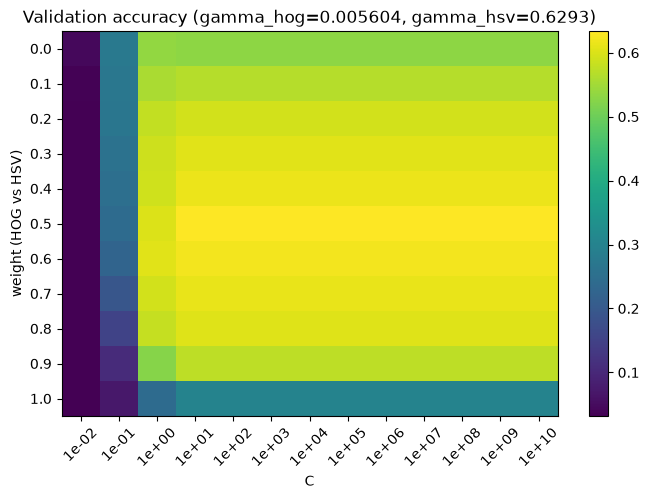

In [ ]:
res_df = pd.DataFrame(results_comb)

#uzimamo one kombinacije koje koriste najbolje gamme za oba histograma
best_g_hog = best_comb["gamma_hog"]
best_g_hsv = best_comb["gamma_hsv"]
sub = res_df[(res_df["gamma_hog"] == best_g_hog) & (res_df["gamma_hsv"] == best_g_hsv)]

pivot = sub.pivot(index="weight", columns="C", values="acc")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{c:.0e}' for c in pivot.columns], rotation=45)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{w:.1f}' for w in pivot.index])

ax.set_xlabel("C")
ax.set_ylabel("weight (HOG vs HSV)")
ax.set_title(f"Validation accuracy (gamma_hog={best_g_hog:.4g}, gamma_hsv={best_g_hsv:.4g})")
plt.colorbar(im, ax=ax)
plt.show()

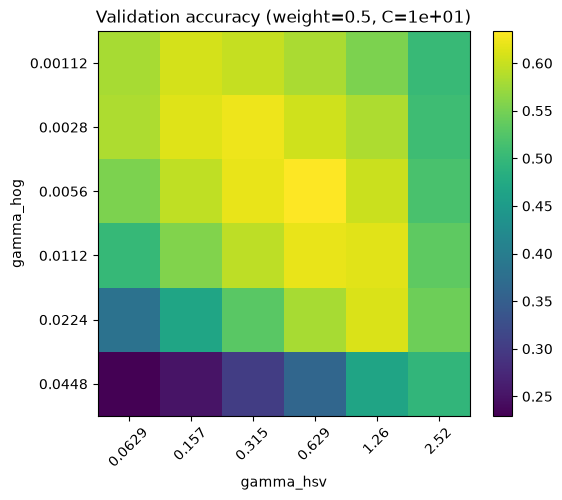

In [ ]:
best_w = best_comb["weight"]
best_C = best_comb["C"]
sub = res_df[(res_df["weight"] == best_w) & (res_df["C"] == best_C)]

pivot = sub.pivot(index="gamma_hog", columns="gamma_hsv", values="acc")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pivot.values, aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{g:.3g}' for g in pivot.columns], rotation=45)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{g:.3g}' for g in pivot.index])

ax.set_xlabel("gamma_hsv")
ax.set_ylabel("gamma_hog")
ax.set_title(f"Validation accuracy (weight={best_w:.1f}, C={best_C:.0e})")
plt.colorbar(im, ax=ax)
plt.show()

In [ ]:
w = best_comb["weight"]
C = best_comb["C"]
g_hog = best_comb["gamma_hog"]
g_hsv = best_comb["gamma_hsv"]

Khog_tr = chi2_kernel_from_s(s_hog_tr, g_hog)
Khog_te = chi2_kernel_from_s(s_hog_te, g_hog)

Khsv_tr = chi2_kernel_from_s(s_hsv_tr, g_hsv)
Khsv_te = chi2_kernel_from_s(s_hsv_te, g_hsv)

Kcomb_tr = w * normalize_K(Khog_tr) + (1 - w) * normalize_K(Khsv_tr)
Kcomb_te = w * normalize_K(Khog_te) + (1 - w) * normalize_K(Khsv_te)

y_test_pred, test_acc = eval_precomputed_SVC(Kcomb_tr, Kcomb_te, y_train, y_test, C)
print(f"Test accuracy for combined HOG + HSV SVM: ", test_acc)

Test accuracy for combined HOG + HSV SVM:  0.6411716842961758


### Segmentacija slika ?

### Konvolucione neuronske mreze 

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import time

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [29]:
num_classes = len(np.unique(df['label'].values))
label_to_idx = {label: idx for idx, label in enumerate(sorted(np.unique(df['label'].values)))}
print("Number of classes:", num_classes)

Number of classes: 102


In [30]:
CNN_IMG_SIZE = 128

In [31]:
class FlowerDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = label_to_idx[self.labels[idx]]
        return img, label

In [32]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [33]:
train_transform = transforms.Compose([
    transforms.Resize((CNN_IMG_SIZE, CNN_IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [34]:
eval_transform = transforms.Compose([
    transforms.Resize((CNN_IMG_SIZE, CNN_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [35]:
train_ds = FlowerDataset(X_train, y_train, transform=train_transform)
val_ds   = FlowerDataset(X_val,   y_val,   transform=eval_transform)
test_ds  = FlowerDataset(X_test,  y_test,  transform=eval_transform)

In [36]:
BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
print(next(iter(train_loader)))

Train batches: 180, Val batches: 39, Test batches: 39
[tensor([[[[-2.1008, -2.1008, -2.1008,  ..., -2.1008, -2.1008, -2.1008],
          [-2.1008, -2.1008, -2.1008,  ..., -2.1008, -2.1008, -2.1008],
          [-2.1008, -2.1008, -2.1008,  ..., -2.1008, -2.1008, -2.1008],
          ...,
          [-2.1008, -2.1008, -2.1008,  ..., -2.1008, -2.1008, -2.1008],
          [-2.1008, -2.1008, -2.1008,  ..., -2.1008, -2.1008, -2.1008],
          [-2.1008, -2.1008, -2.1008,  ..., -2.1008, -2.1008, -2.1008]],

         [[-2.0182, -2.0182, -2.0182,  ..., -2.0182, -2.0182, -2.0182],
          [-2.0182, -2.0182, -2.0182,  ..., -2.0182, -2.0182, -2.0182],
          [-2.0182, -2.0182, -2.0182,  ..., -2.0182, -2.0182, -2.0182],
          ...,
          [-2.0182, -2.0182, -2.0182,  ..., -2.0182, -2.0182, -2.0182],
          [-2.0182, -2.0182, -2.0182,  ..., -2.0182, -2.0182, -2.0182],
          [-2.0182, -2.0182, -2.0182,  ..., -2.0182, -2.0182, -2.0182]],

         [[-1.7870, -1.7870, -1.7870,  ..., -1.

In [37]:
class FlowerCNN(nn.Module):
    def __init__(self, num_classes, img_size=CNN_IMG_SIZE, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # img_size / 2

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # img_size / 4

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # img_size / 8

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # img_size / 16
        )

        feat_size = img_size // 16
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * feat_size * feat_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [38]:
model = FlowerCNN(num_classes=num_classes).to(device)

In [39]:
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

FlowerCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, af

In [49]:
def run_epoch(model, loader, criterion, optimizer=None, step_counter=None, metrics=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_correct, total_samples = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if is_train:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            batch_size = imgs.size(0)
            batch_loss = loss.item()
            preds = outputs.argmax(dim=1)
            batch_correct = (preds == labels).sum().item()
            batch_acc = batch_correct / batch_size

            total_loss += batch_loss * batch_size
            total_correct += batch_correct
            total_samples += batch_size

            if is_train and metrics is not None and step_counter is not None:
                step_counter[0] += 1
                metrics["train_loss"].append(batch_loss)
                metrics["train_acc"].append(batch_acc)
                metrics["train_steps"].append(step_counter[0])

    return total_loss / total_samples, total_correct / total_samples

In [50]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=100, patience=7, save_path="assets/best_cnn_model.pt"):
    best_val_acc = 0.0
    patience_counter = 0

    metrics = {"train_loss": [], "train_acc": [], "train_steps": [], "val_loss": [], "val_acc": [], "val_steps": []}
    global_step = [0]
    for epoch in range(1, num_epochs + 1):

        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, step_counter=global_step, metrics=metrics)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

        scheduler.step(val_acc)

        metrics["val_loss"].append(val_loss)
        metrics["val_acc"].append(val_acc)
        metrics["val_steps"].append(global_step[0])

        print(f"Epoch {epoch}/{num_epochs}: "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    return best_val_acc, metrics

In [51]:
lr_values = [1e-2, 1e-3, 5e-4, 1e-4]
wd_values = [0, 1e-5, 1e-4, 1e-3]
dropout_values = [0.3, 0.5]
# batch_sizes = [32, 64, 128]

In [53]:
import itertools

search_results = []

for lr, wd, dropout in itertools.product(lr_values, wd_values, dropout_values):
    model = FlowerCNN(num_classes=num_classes, dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    best_acc, _ = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                               num_epochs=30, patience=4,
                               save_path=f"assets/tmp/tmp_lr{lr}_wd{wd}_do{dropout}.pt")

    search_results.append({"lr": lr, "wd": wd, "dropout": dropout, "val_acc": best_acc})
    print(f"lr={lr}, wd={wd}, dropout={dropout} -> val_acc={best_acc:.4f}")

best_config = max(search_results, key=lambda r: r["val_acc"])
print("Best config:", best_config)

Epoch 1/30: train_loss=9.8398 train_acc=0.0251 val_loss=4.5448 val_acc=0.0317
Epoch 2/30: train_loss=4.5399 train_acc=0.0314 val_loss=4.5257 val_acc=0.0317
Epoch 3/30: train_loss=4.5311 train_acc=0.0314 val_loss=4.5221 val_acc=0.0317
Epoch 4/30: train_loss=4.5296 train_acc=0.0314 val_loss=4.5213 val_acc=0.0317
Epoch 5/30: train_loss=4.5265 train_acc=0.0314 val_loss=4.5211 val_acc=0.0317
Early stopping at epoch 5
lr=0.01, wd=0, dropout=0.3 -> val_acc=0.0317
Epoch 1/30: train_loss=8.4635 train_acc=0.0202 val_loss=4.5400 val_acc=0.0236
Epoch 2/30: train_loss=4.5365 train_acc=0.0272 val_loss=4.5234 val_acc=0.0309
Epoch 3/30: train_loss=4.5305 train_acc=0.0295 val_loss=4.5214 val_acc=0.0309
Epoch 4/30: train_loss=4.5292 train_acc=0.0279 val_loss=4.5212 val_acc=0.0317
Epoch 5/30: train_loss=4.5292 train_acc=0.0304 val_loss=4.5211 val_acc=0.0317
Epoch 6/30: train_loss=4.5294 train_acc=0.0314 val_loss=4.5212 val_acc=0.0317
Epoch 7/30: train_loss=4.5298 train_acc=0.0290 val_loss=4.5210 val_acc=

In [54]:
model = FlowerCNN(num_classes=num_classes, dropout=best_config["dropout"]).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=best_config["lr"], weight_decay=best_config["wd"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

best_val_acc, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                                     num_epochs=100, patience=7, save_path="assets/best_cnn_model.pt")
print(f"Best validation accuracy: {best_val_acc}")

Epoch 1/100: train_loss=4.1997 train_acc=0.1000 val_loss=3.7203 val_acc=0.1782
Epoch 2/100: train_loss=3.6769 train_acc=0.1838 val_loss=3.2716 val_acc=0.2840
Epoch 3/100: train_loss=3.3179 train_acc=0.2752 val_loss=3.0051 val_acc=0.3385
Epoch 4/100: train_loss=3.0765 train_acc=0.3316 val_loss=2.8768 val_acc=0.3914
Epoch 5/100: train_loss=2.8879 train_acc=0.3827 val_loss=2.6980 val_acc=0.4337
Epoch 6/100: train_loss=2.7355 train_acc=0.4286 val_loss=2.6124 val_acc=0.4557
Epoch 7/100: train_loss=2.5921 train_acc=0.4663 val_loss=2.4814 val_acc=0.5069
Epoch 8/100: train_loss=2.5054 train_acc=0.4908 val_loss=2.3780 val_acc=0.5354
Epoch 9/100: train_loss=2.4045 train_acc=0.5246 val_loss=2.3423 val_acc=0.5517
Epoch 10/100: train_loss=2.3194 train_acc=0.5473 val_loss=2.2405 val_acc=0.5899
Epoch 11/100: train_loss=2.2404 train_acc=0.5759 val_loss=2.2308 val_acc=0.5728
Epoch 12/100: train_loss=2.1552 train_acc=0.6051 val_loss=2.1824 val_acc=0.5932
Epoch 13/100: train_loss=2.1103 train_acc=0.6223 

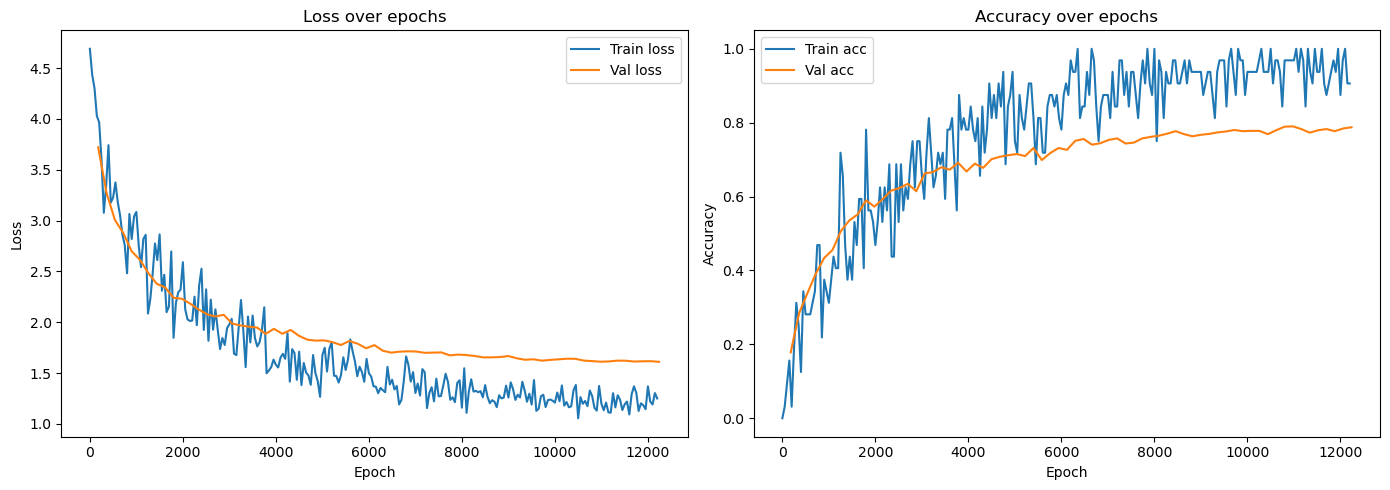

In [60]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(metrics["train_steps"][::50], metrics["train_loss"][::50], label="Train loss")
ax1.plot(metrics["val_steps"], metrics["val_loss"], label="Val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss over epochs")
ax1.legend()

ax2.plot(metrics["train_steps"][::50], metrics["train_acc"][::50], label="Train acc")
ax2.plot(metrics["val_steps"], metrics["val_acc"], label="Val acc")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy over epochs")
ax2.legend()

plt.tight_layout()
plt.show()

In [56]:
model.load_state_dict(torch.load("assets/best_cnn_model.pt"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc_cnn = (all_preds == all_labels).mean()
print(f"Test accuracy for CNN: {test_acc_cnn:.4f}")

C:\Users\ACV001\AppData\Local\Temp\ipykernel_49944\2652080484.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("assets/best_cnn_model.pt"

Test accuracy for CNN: 0.7803


In [57]:
idx_to_label = {v: k for k, v in label_to_idx.items()}
target_names = [str(idx_to_label[i]) for i in range(num_classes)]

print(classification_report(all_labels, all_preds, target_names=target_names, digits=4, zero_division=0))

              precision    recall  f1-score   support

           1     1.0000    0.8333    0.9091         6
           2     1.0000    0.8889    0.9412         9
           3     0.1667    0.1667    0.1667         6
           4     0.8000    0.5000    0.6154         8
           5     0.8182    0.9000    0.8571        10
           6     0.8571    0.8571    0.8571         7
           7     0.8000    0.6667    0.7273         6
           8     1.0000    1.0000    1.0000        13
           9     0.5000    0.5714    0.5333         7
          10     1.0000    1.0000    1.0000         7
          11     0.8571    0.4615    0.6000        13
          12     0.7143    0.7692    0.7407        13
          13     0.8571    0.8571    0.8571         7
          14     0.8750    1.0000    0.9333         7
          15     0.7500    0.8571    0.8000         7
          16     0.5714    0.6667    0.6154         6
          17     1.0000    0.8462    0.9167        13
          18     0.7500    

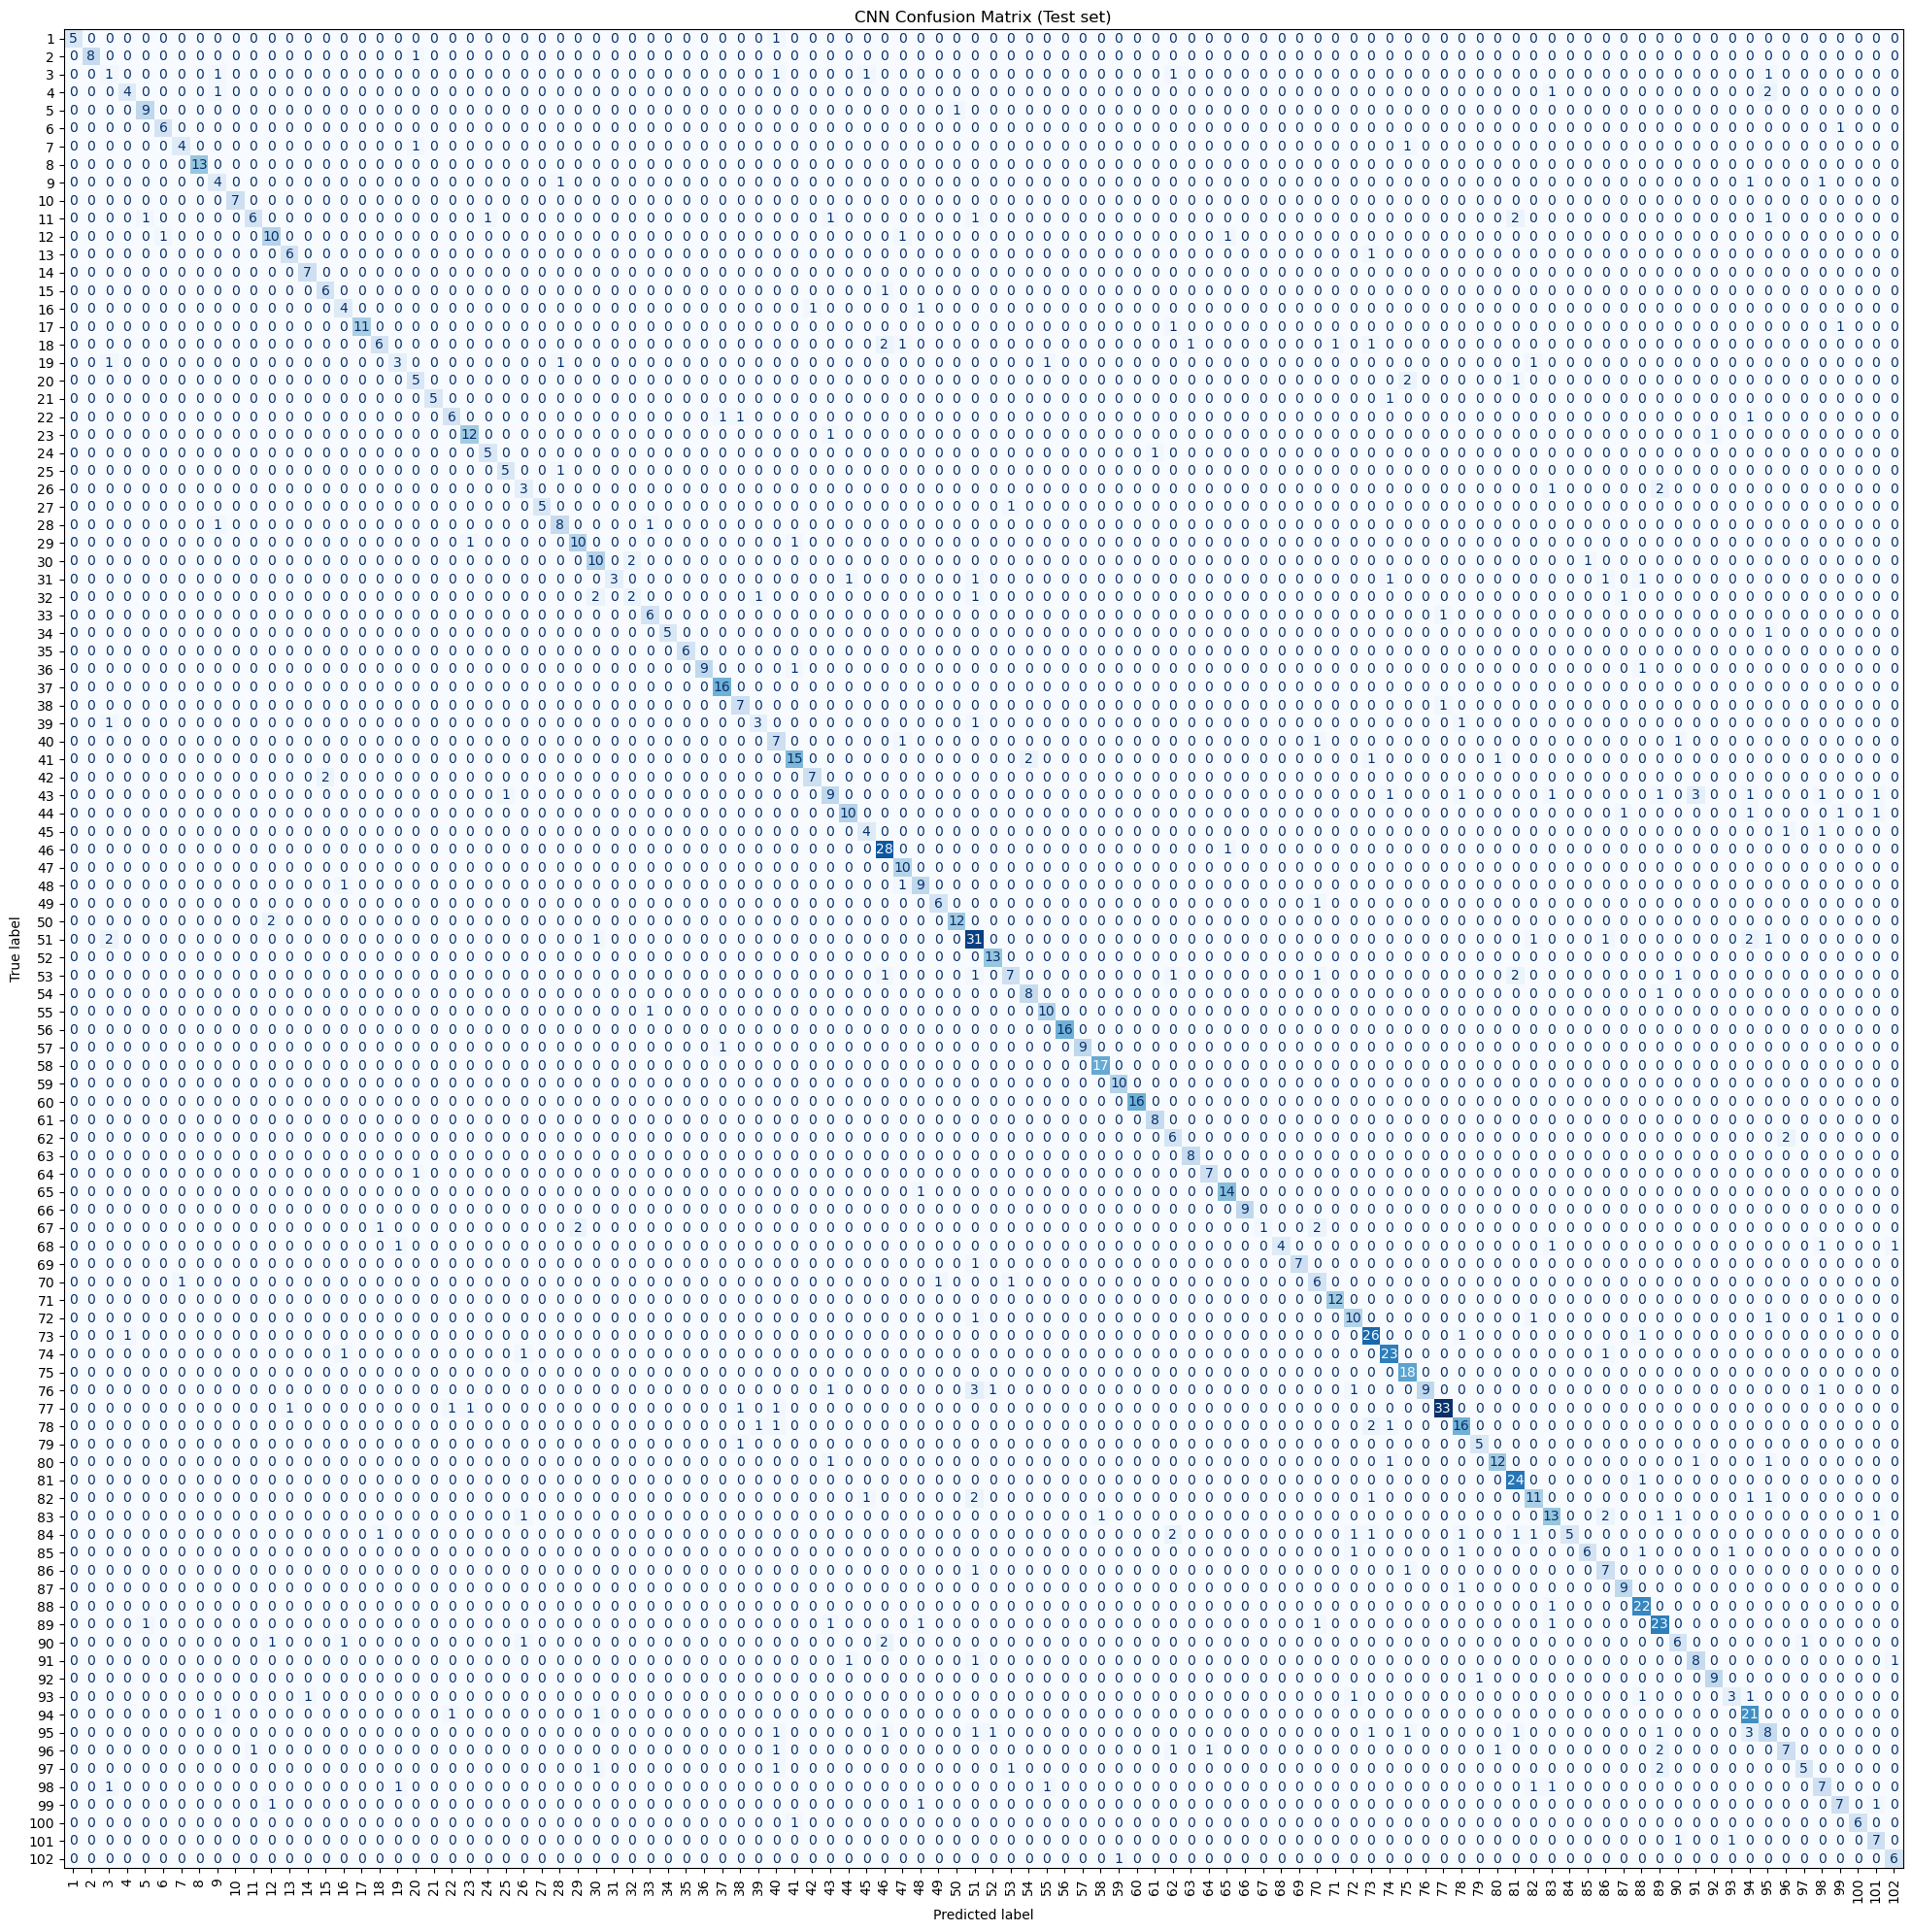

In [58]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(20, 20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, colorbar=False, values_format='d')
ax.set_title("CNN Confusion Matrix (Test set)")
plt.tight_layout()
plt.show()

In [99]:
#malo bolji prikaz dijagonale
from collections import Counter
test_counter = Counter(y_test)
diagonal = cm.diagonal()
for i in range(len(diagonal)):
    el_total = test_counter.get(i+1)
    el_diagonal = diagonal[i]
    print(f"{i+1}: {el_diagonal} / {el_total}")

1: 5 / 6
2: 8 / 9
3: 1 / 6
4: 4 / 8
5: 9 / 10
6: 6 / 7
7: 4 / 6
8: 13 / 13
9: 4 / 7
10: 7 / 7
11: 6 / 13
12: 10 / 13
13: 6 / 7
14: 7 / 7
15: 6 / 7
16: 4 / 6
17: 11 / 13
18: 6 / 12
19: 3 / 7
20: 5 / 8
21: 5 / 6
22: 6 / 9
23: 12 / 14
24: 5 / 6
25: 5 / 6
26: 3 / 6
27: 5 / 6
28: 8 / 10
29: 10 / 12
30: 10 / 13
31: 3 / 8
32: 2 / 7
33: 6 / 7
34: 5 / 6
35: 6 / 6
36: 9 / 11
37: 16 / 16
38: 7 / 8
39: 3 / 6
40: 7 / 10
41: 15 / 19
42: 7 / 9
43: 9 / 20
44: 10 / 14
45: 4 / 6
46: 28 / 29
47: 10 / 10
48: 9 / 11
49: 6 / 7
50: 12 / 14
51: 31 / 39
52: 13 / 13
53: 7 / 14
54: 8 / 9
55: 10 / 11
56: 16 / 16
57: 9 / 10
58: 17 / 17
59: 10 / 10
60: 16 / 16
61: 8 / 8
62: 6 / 8
63: 8 / 8
64: 7 / 8
65: 14 / 15
66: 9 / 9
67: 1 / 6
68: 4 / 8
69: 7 / 8
70: 6 / 9
71: 12 / 12
72: 10 / 14
73: 26 / 29
74: 23 / 26
75: 18 / 18
76: 9 / 16
77: 33 / 38
78: 16 / 21
79: 5 / 6
80: 12 / 16
81: 24 / 25
82: 11 / 17
83: 13 / 20
84: 5 / 13
85: 6 / 10
86: 7 / 9
87: 9 / 10
88: 22 / 23
89: 23 / 28
90: 6 / 12
91: 8 / 11
92: 9 / 10
93: 3 

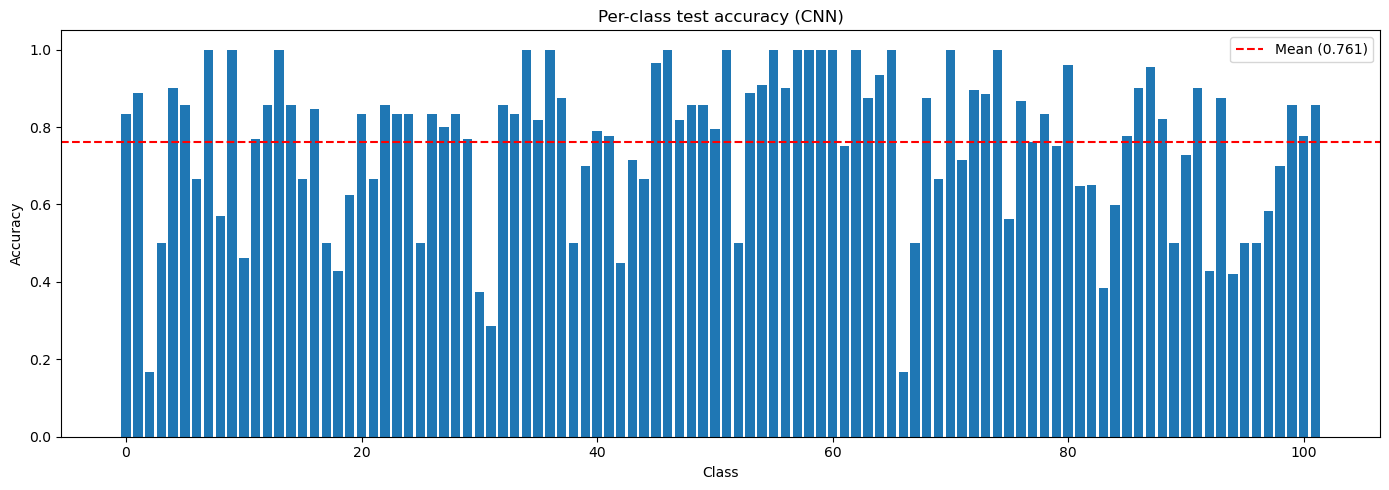

Worst classes: [67, 3, 32, 31, 84]
Best classes: [75, 37, 71, 59, 60]


In [59]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(num_classes), per_class_acc)
ax.set_xlabel("Class")
ax.set_ylabel("Accuracy")
ax.set_title("Per-class test accuracy (CNN)")
ax.axhline(per_class_acc.mean(), color='red', linestyle='--', label=f'Mean ({per_class_acc.mean():.3f})')
ax.legend()
plt.tight_layout()
plt.show()

sorted_idx = np.argsort(per_class_acc)
print(f"Worst classes: {[idx_to_label[i] for i in sorted_idx[:5]]}")
print(f"Best classes: {[idx_to_label[i] for i in sorted_idx[-5:]]}")


### Analiza -  gde model najcesce gresi? Zasto?

### Pritrenirana mreza ? npr. ResNet
https://ieeexplore.ieee.org/document/10837881